# PART 2 : FORMAT-STYLE COMPARISON

## IMPORTS

In [52]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Compare:
• video duration / title length / description length
• focus on title : punctuation (question / exclamation marks) + calls to action (lien en description)
• calls to action (lien en description)
=> + evolution

In [53]:
COLOR_INST = "#FC8D62"
COLOR_IND = "#66C2A5"

COLOR_MAP = {"Institutional": COLOR_INST, "Independent": COLOR_IND}

## SET-UP

In [54]:
data = pd.read_csv("../../processed/videos.csv")
channel_data = pd.read_csv("../../processed/channels.csv")

In [55]:
data.head()

,video_id,channel_id,published_at,title,description,duration_iso8601,duration_seconds,view_count,like_count,comment_count,thumbnail_url_default,thumbnail_url_high,tags,privacy_status_if_available
0,--4MpKow8ro,UC-EnprmCZ3OXyAoG7vjVNCA,2011-06-07T00:01:03Z,NExT: Bing Overseas Studies,"(June 2, 2011) Students Aleema Jamal and Matth...",PT2M7S,127.0,3119.0,8.0,1.0,https://i.ytimg.com/vi/--4MpKow8ro/default.jpg,https://i.ytimg.com/vi/--4MpKow8ro/hqdefault.jpg,Undergraduate Education|Diversity|Culture|Hist...,public
1,--ZfVZbmKbY,UC-EnprmCZ3OXyAoG7vjVNCA,2017-05-07T22:57:29Z,Mark Hartney: ARPA-E and Funding R&D of Advanc...,Mark Hartney is the director of the Office of ...,PT1H2M51S,3771.0,4314.0,38.0,NaN,https://i.ytimg.com/vi/--ZfVZbmKbY/default.jpg,https://i.ytimg.com/vi/--ZfVZbmKbY/hqdefault.jpg,NaN,public
2,--aYHgPKGIs,UCRNo2gqj3GiHlmT_OnqkouA,2017-06-15T05:47:25Z,ETH Zürich: Bereit?,Dann Los! Erfahre in 120 Sekunden das Wichtigs...,PT2M9S,129.0,99700.0,1038.0,17.0,https://i.ytimg.com/vi/--aYHgPKGIs/default.jpg,https://i.ytimg.com/vi/--aYHgPKGIs/hqdefault.jpg,ETH Zürich|ETH|Hochschule|Universität|Spitzenf...,public
3,--qKOhdgJAs,UC-EnprmCZ3OXyAoG7vjVNCA,2021-05-24T15:00:17Z,Lecture 3: MVVM and the Swift type system,Lecture 3 of Stanford’s Spring 2021 iteration ...,PT1H35M48S,5748.0,178472.0,2432.0,NaN,https://i.ytimg.com/vi/--qKOhdgJAs/default.jpg,https://i.ytimg.com/vi/--qKOhdgJAs/hqdefault.jpg,Swift|SwiftUI|Xcode|iOS|iPhone|iPad|Stanford|C...,public
4,--sBEWfPfKA,UC-EnprmCZ3OXyAoG7vjVNCA,2019-10-16T20:12:38Z,Stanford course teaches neuroscience through r...,"To bring neuroscience down to earth, two Stanf...",PT3M20S,200.0,11831.0,321.0,NaN,https://i.ytimg.com/vi/--sBEWfPfKA/default.jpg,https://i.ytimg.com/vi/--sBEWfPfKA/hqdefault.jpg,Stanford|Stanford University|Climb|Climbing|Ro...,public


In [56]:
channel_data.head()

,channel_id,channel_title,channel_description,channel_published_at,uploads_playlist_id,group_label
0,UCUHW94eEFW7hkUMVaZz4eDg,minutephysics,Simply put: cool physics and other sweet scien...,2011-06-20T18:20:09Z,UUUHW94eEFW7hkUMVaZz4eDg,independent
1,UCiEHVhv0SBMpP75JbzJShqw,Lectures by Walter Lewin. They will make you ♥...,This channel contains the complete 8.01x (Phys...,2015-02-07T15:51:32Z,UUiEHVhv0SBMpP75JbzJShqw,independent
2,UCYO_jab_esuFRV4b17AJtAw,3Blue1Brown,My name is Grant Sanderson. Videos here cover ...,2015-03-03T23:11:55Z,UUYO_jab_esuFRV4b17AJtAw,independent
3,UClMJeVIVyGp-3_kWtspkS0Q,EPFL,We are one of the most international universit...,2010-01-12T12:40:29Z,UUlMJeVIVyGp-3_kWtspkS0Q,institutional
4,UC-EnprmCZ3OXyAoG7vjVNCA,Stanford,From its founding in California in the late 19...,2006-09-19T04:37:21Z,UU-EnprmCZ3OXyAoG7vjVNCA,institutional


In [57]:
data["Institution"] = data["channel_id"].isin(channel_data[channel_data["group_label"] == "institutional"]["channel_id"])
data.groupby("Institution").size()

Institution
False    2548
True     7021
dtype: int64

In [58]:
data["duration_mn"] = data["duration_seconds"] / 60
data["title_len_chars"] = data["title"].str.len()
data["title_len_words"] = data["title"].str.split().str.len()
data["description_len_chars"] = data["description"].str.len()
data["description_len_words"] = data["description"].str.split().str.len()

In [59]:
grouped_data = data.groupby("Institution")

## A. Video / Title / Description Length

In [60]:
print(data.groupby("Institution")[["duration_mn","title_len_chars", "title_len_words", "description_len_chars", "description_len_words"]].describe().round(1).to_string())

            duration_mn                                         title_len_chars                                           title_len_words                                     description_len_chars                                                   description_len_words                                            
                  count  mean   std  min  25%  50%   75%    max           count  mean   std  min   25%   50%   75%    max           count mean  std  min  25%  50%  75%   max                 count   mean     std  min    25%    50%     75%     max                 count  mean    std  min   25%   50%    75%    max
Institution                                                                                                                                                                                                                                                                                                            
False            2547.0   9.1  14.1  0.0  2.0  4.3   9.6  116.0 

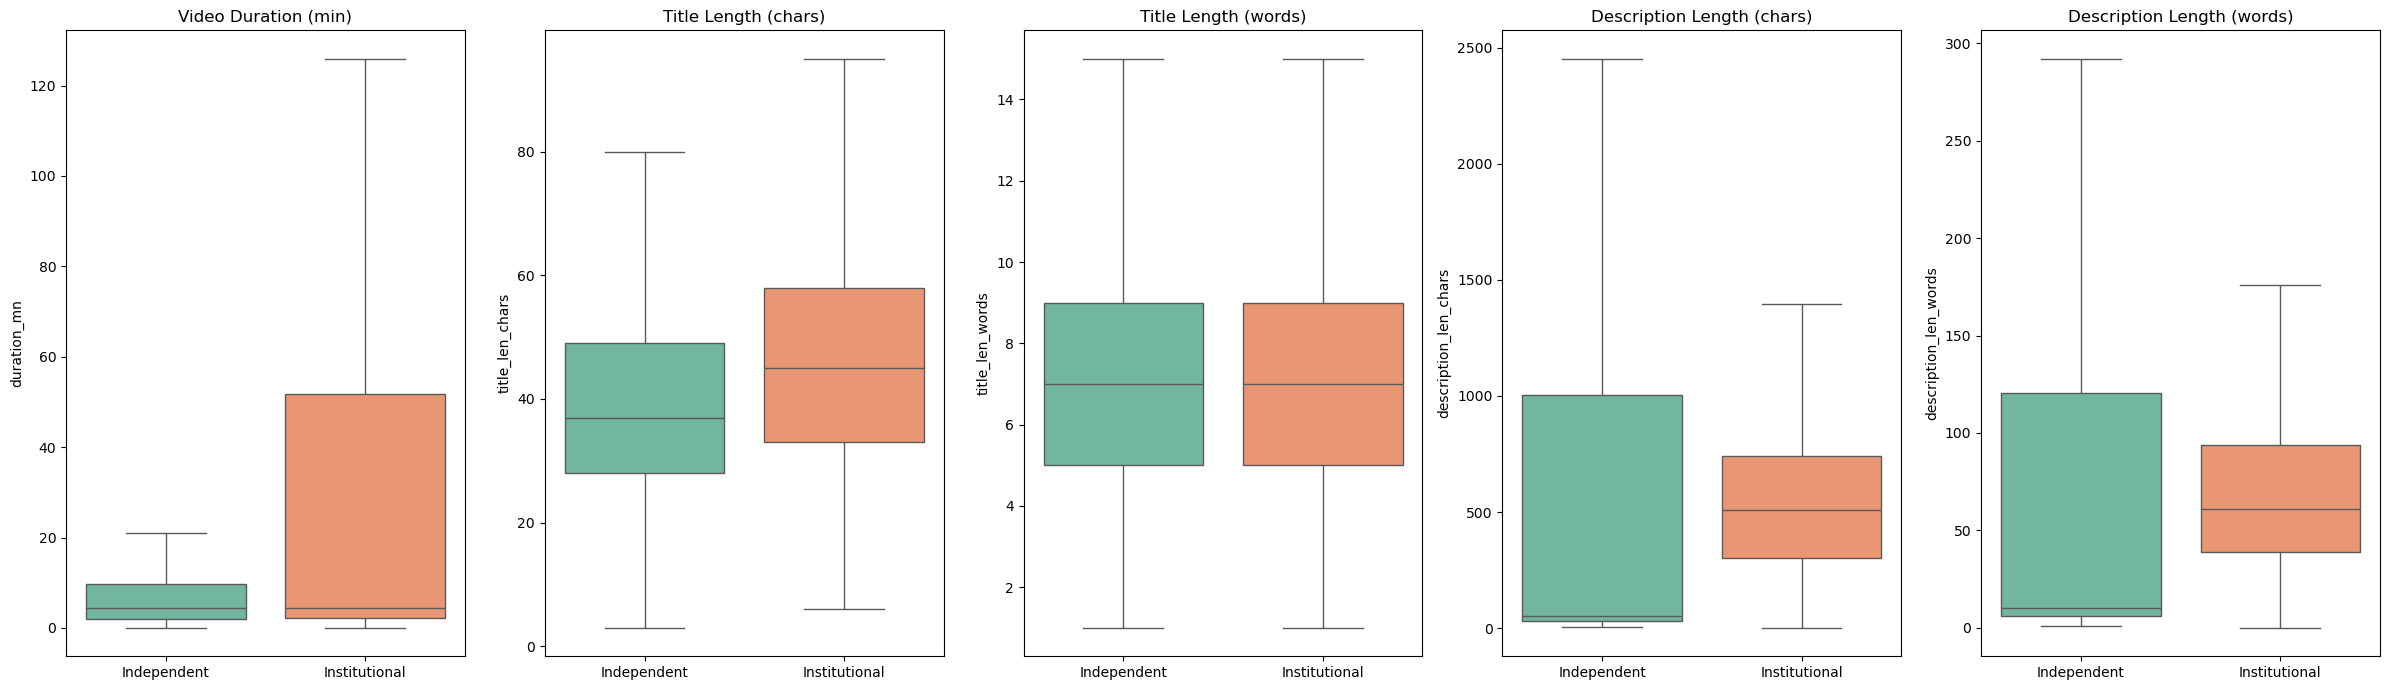

In [61]:
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
metrics = [
    ("duration_mn",          "Video Duration (min)"),
    ("title_len_chars",       "Title Length (chars)"),
    ("title_len_words",       "Title Length (words)"),
    ("description_len_chars",    "Description Length (chars)"),
    ("description_len_words", "Description Length (words)"),    
]

for ax, (col, label) in zip(axes, metrics):
    sns.boxplot(data=data, x="Institution", y=col, ax=ax,
            hue="Institution", palette="Set2", legend=False, showfliers=False)
    ax.set_title(label)
    ax.set_xlabel("" if True else "")
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Independent", "Institutional"])
plt.tight_layout()
plt.show()

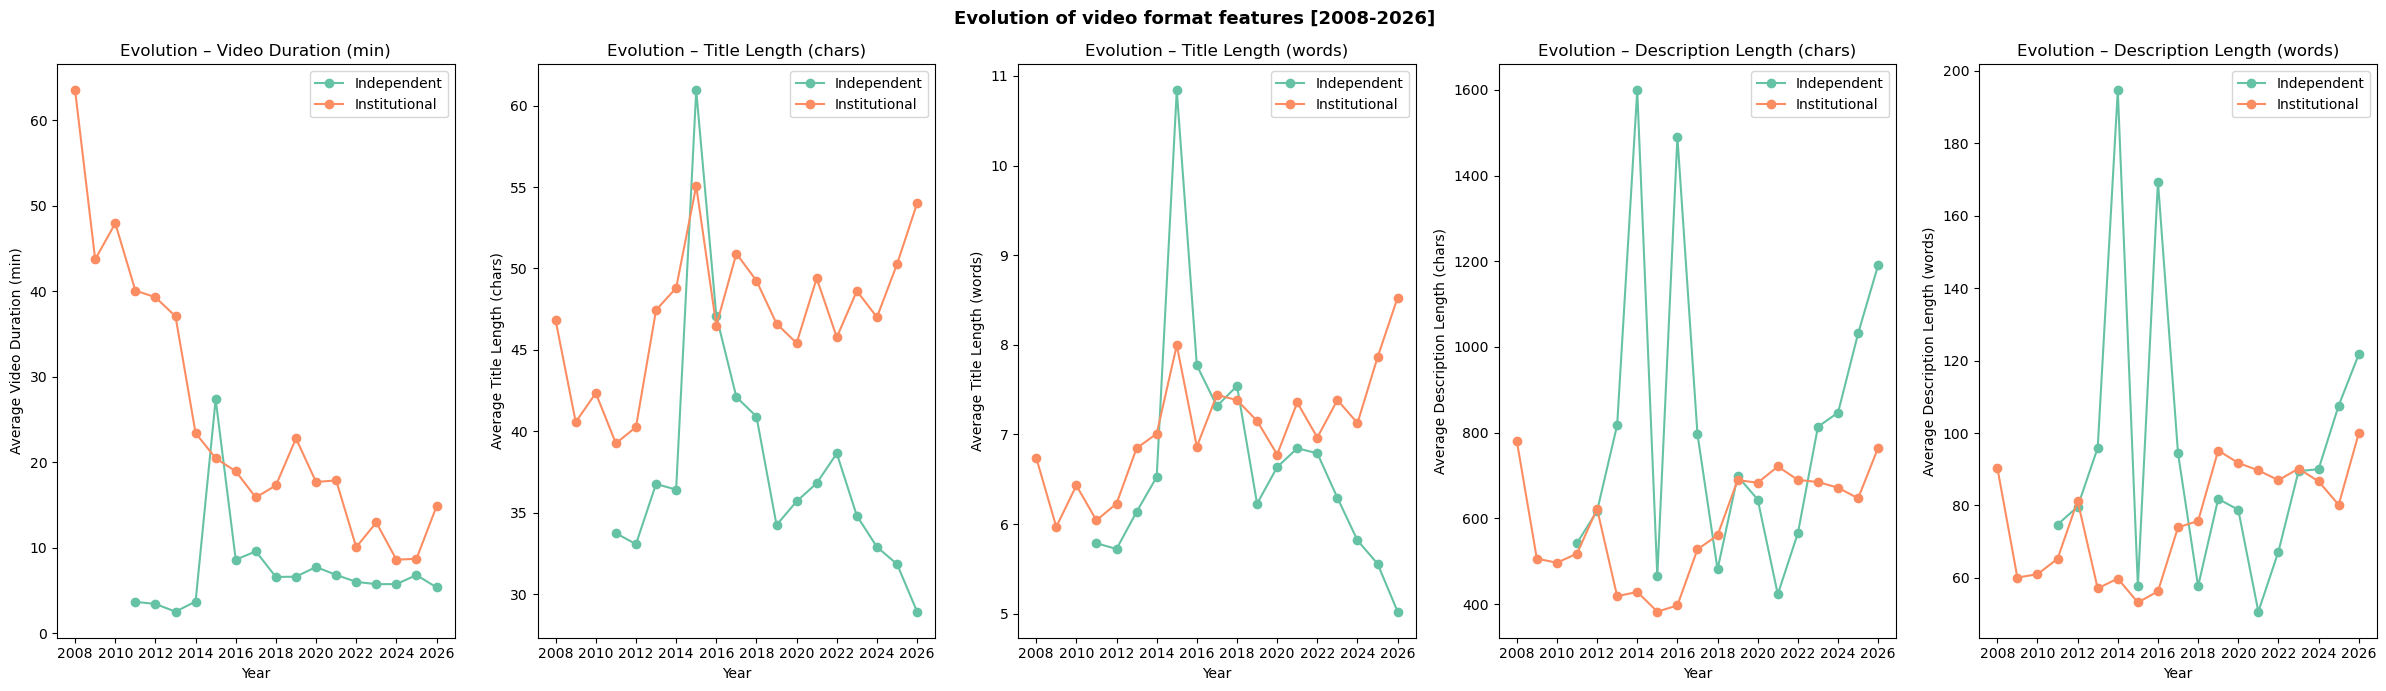

In [62]:
data["published_at"] = pd.to_datetime(data["published_at"], utc=True, errors="coerce")
data["published_year"] = data["published_at"].dt.year

evo_metrics = data.groupby(["published_year","Institution"])[["duration_mn","title_len_chars", "title_len_words", "description_len_chars", "description_len_words"]].mean().reset_index()
evo_metrics["group"] = evo_metrics["Institution"].map({True:"Institutional", False:"Independent"})

fig, axes = plt.subplots(1, 5, figsize=(24, 7))
for ax, (col, label) in zip(axes, metrics):
    for grp, grp_df in evo_metrics.groupby("group"):
        ax.plot(grp_df["published_year"], grp_df[col], marker="o", label=grp, color=COLOR_MAP[grp])
    ax.set_title(f"Evolution – {label}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average " + label)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()
plt.suptitle("Evolution of video format features [2008-2026]", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## B. Focus on title

In [63]:
sia = SentimentIntensityAnalyzer()

def extract_title_features(title: str) -> dict:
    ttl = str(title)
    lower_ttl = ttl.lower().strip()
    words = lower_ttl.split()
    vader = sia.polarity_scores(ttl)
    return {
        "title_len_chars":    len(ttl),
        "title_len_words":    len(words),
        "has_question_mark":       int('?' in ttl),
        "has_exclamation_mark":    int('!' in ttl),
        "has_figure":         int(bool(re.search(r'\d', ttl))),
        "starts_with_how":    int(lower_ttl.startswith('how')),
        'starts_with_why':    int(lower_ttl.startswith('why')),
        'starts_with_what':   int(lower_ttl.startswith('what')), 
    }

features = data['title'].apply(extract_title_features).apply(pd.Series)
concat_data = pd.concat([data, features], axis=1)

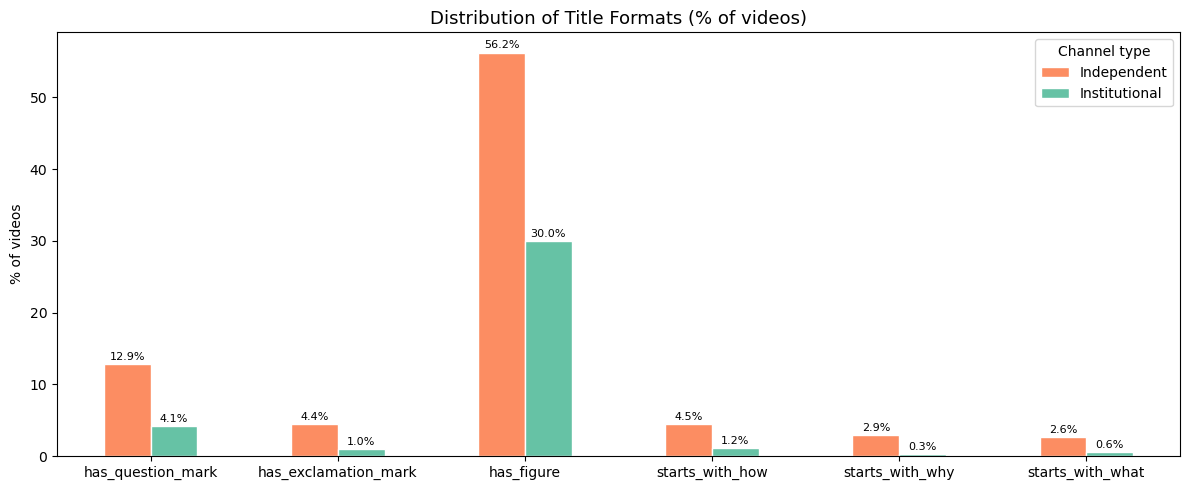

In [64]:
binary_feats = [
    "has_question_mark","has_exclamation_mark",
    "has_figure", "starts_with_how","starts_with_why","starts_with_what",
]
feat_pct = (
    concat_data.groupby("Institution")[binary_feats]
    .mean()
    .mul(100)
    .rename(index={True:"Institutional", False:"Independent"})
    .T
)
feat_pct.columns.name = None

ax = feat_pct.plot(kind="bar", figsize=(12, 5), color=[COLOR_INST, COLOR_IND], edgecolor="white")
ax.set_title("Distribution of Title Formats (% of videos)", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel type")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


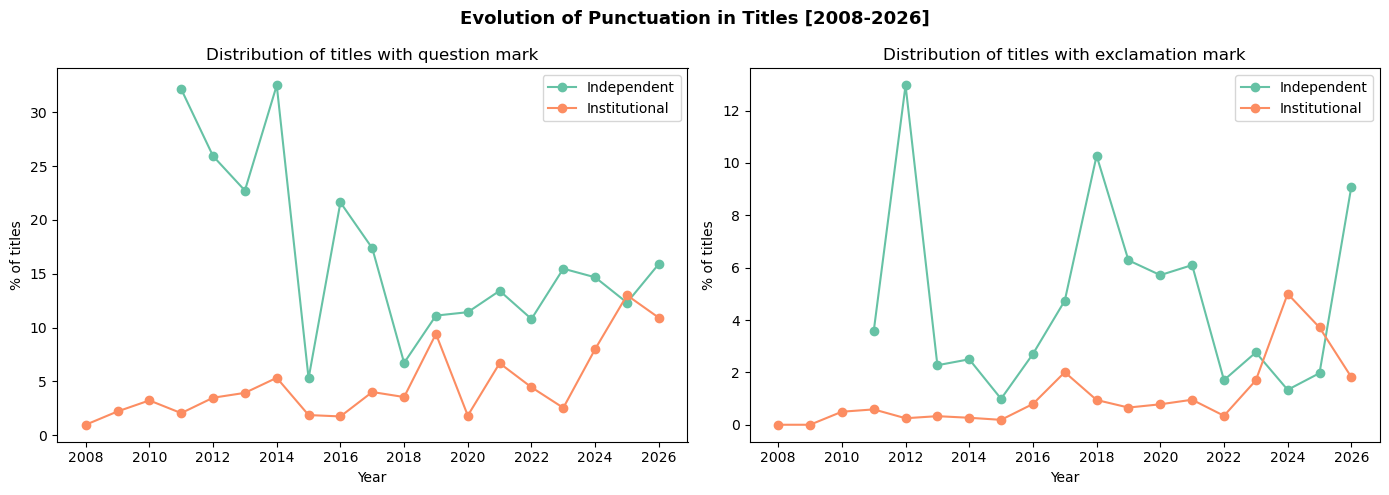

In [ ]:
evo_punct = (
    concat_data.groupby(["published_year","Institution"])[["has_question_mark","has_exclamation_mark"]]
    .mean().mul(100).reset_index()
)
evo_punct["group"] = evo_punct["Institution"].map({True:"Institutional", False:"Independent"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes,
                           ["has_question_mark","has_exclamation_mark"],
                           ["Distribution of titles with question mark","Distribution of titles with exclamation mark"]):
    for grp, gdf in evo_punct.groupby("group"):
        ax.plot(gdf["published_year"], gdf[col], marker="o", label=grp, color=COLOR_MAP[grp])
    ax.set_title(f"{label}")
    ax.set_xlabel("Year"); ax.set_ylabel("% of titles")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(title="Channel type")
plt.suptitle("Evolution of Punctuation in Titles [2008-2026]", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## C. Call to action

Different ways to check the call to actions :
- Whether the videos contains links in the description
- If so, how many
- Call to comment / like / check out the links

In [66]:
URL_FORMAT = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
CTA_BANK_WORDS = r'subscribe|follow|like|comment|share|click|check|link'

def count_links(desc):
    if pd.isna(desc):
        return 0
    return len(URL_FORMAT.findall(str(desc)))

def count_cta(desc):
    if pd.isna(desc):
        return 0
    return int(bool(re.search(CTA_BANK_WORDS, str(desc).lower())))

concat_data["nb_links"] = concat_data["description"].apply(count_links)
concat_data["has_link"] = (concat_data["nb_links"] > 0).astype("int64")
concat_data["nb_cta"] = concat_data["description"].apply(count_cta)
concat_data["has_cta"] = (concat_data["nb_cta"] > 0).astype("int64")

print(concat_data.groupby("Institution")[["has_link", "nb_links", "has_cta", "nb_cta"]].mean().mul(100).round(1))

             has_link  nb_links  has_cta  nb_cta
Institution                                     
False            38.6     532.6     29.1    29.1
True             68.9     212.7     22.6    22.6


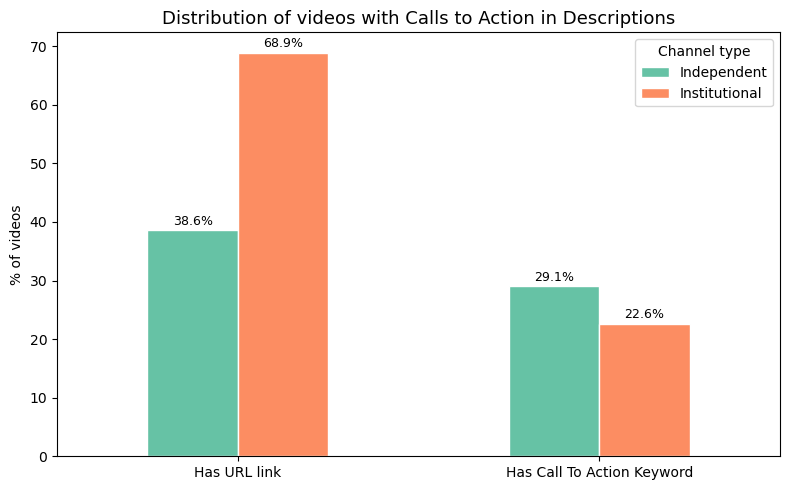

In [69]:
cta_pct = (
    concat_data.groupby("Institution")[["has_link","has_cta"]]
    .mean().mul(100)
    .rename(index={True:"Institutional", False:"Independent"},
            columns={"has_link":"Has URL link","has_cta":"Has Call To Action Keyword"})
    .T
)
ax = cta_pct.plot(kind="bar", figsize=(8, 5), color=COLOR_MAP, edgecolor="white")
ax.set_title("Distribution of videos with Calls to Action in Descriptions", fontsize=13)
ax.set_ylabel("% of videos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.4),
                ha="center", va="bottom", fontsize=9)
ax.legend(title="Channel type")
plt.tight_layout()
plt.show()

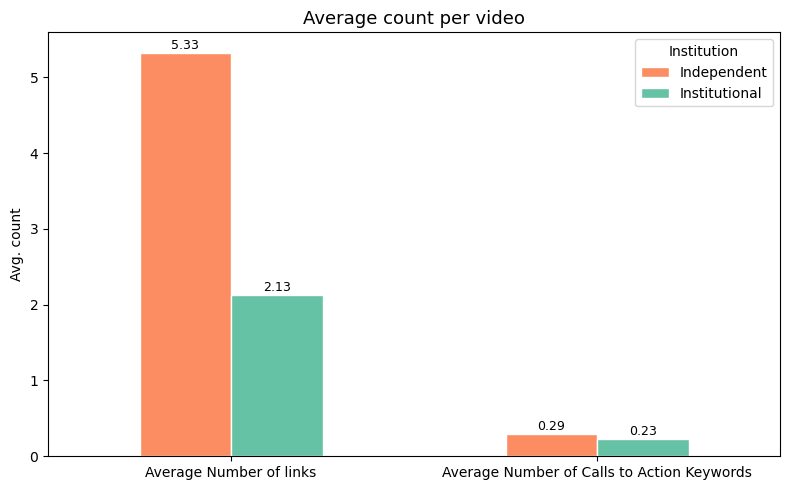

In [68]:
count_avg = (
    concat_data.groupby("Institution")[["nb_links","nb_cta"]]
    .mean()
    .rename(index={True:"Institutional", False:"Independent"},
            columns={"nb_links":"Average Number of links","nb_cta":"Average Number of Calls to Action Keywords"})
    .T
)
ax = count_avg.plot(kind="bar", figsize=(8, 5), color=[COLOR_INST, COLOR_IND], edgecolor="white")
ax.set_title("Average count per video", fontsize=13)
ax.set_ylabel("Avg. count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()